# Experiment 1: tiling a long single-topic passage

**Question.** When a long section talks about one topic, how does the tiler split it? How many semantic units appear, and are they sensible?

This is a lab notebook, not a test: no assertions, just observation. The passage below is 40 sentences, all about a single subject (the borrowing rules of a public library), written with the natural sub-facets such a section has: registration, limits, renewals, reservations, fines, returns, special items, reminders, privacy.

We run the real production embedder (`Qwen3-Embedding-4B`), so what we see matches what the library does in practice.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch

from text_change_detector.shared.embedder import SentenceTransformerEmbedder
from text_change_detector.shared.graph import knn_sparsify
from text_change_detector.shared.models import Segment
from text_change_detector.tiling import pipeline
from text_change_detector.tiling.pipeline import tile

/home/marek/repos/priv/text_change_detector/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def pick_device():
    if torch.cuda.is_available() and torch.cuda.mem_get_info()[0] > 9 * 1024 ** 3:
        return 'cuda'

    return 'cpu'


DEVICE = pick_device()
embedder = SentenceTransformerEmbedder(device=DEVICE, batch_size=8)

print('device:', DEVICE)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 748.46it/s]


device: cuda


## The input: 40 sentences, one topic

In [3]:
SENTENCES = [
    'The city library lends books to any resident who holds a valid membership card.',
    'A new member registers at the front desk by presenting a photo ID and proof of address.',
    'The librarian then issues a card that is valid for three years from the date of registration.',
    'Each member may borrow up to ten books at a time.',
    'The standard loan period for a book is twenty-one days.',
    'A member can check the due date printed on the receipt handed out at the counter.',
    'Borrowed books may be renewed twice if no other reader has reserved them.',
    'A renewal extends the loan by a further twenty-one days from the day it is granted.',
    "Members renew a book either at the desk or through the library's online catalogue.",
    'When a title is already on loan, a member may place a reservation on it.',
    'The system notifies the member by email as soon as a reserved book is returned.',
    'A reserved book is then held at the pickup shelf for seven days.',
    'If the member does not collect it within that week, the reservation is cancelled.',
    "Returning a book on time keeps the member's account in good standing.",
    'A book returned after its due date incurs a fine of twenty cents per day.',
    'The fine stops accruing once the outstanding balance reaches ten euros for a single title.',
    'Members can pay their fines at the desk or online through the member portal.',
    'An account with unpaid fines above five euros is blocked from further borrowing.',
    'The block is lifted automatically the moment the balance falls back below that limit.',
    'Books may be returned to the front desk during opening hours.',
    'Outside opening hours, members drop books into the return bin beside the main entrance.',
    'Staff empty the return bin every morning and check each book back into the system.',
    'A book is only counted as returned once staff have scanned it at the desk.',
    'Damaged books are set aside for the repair team to assess.',
    'A member who returns a badly damaged book may be charged its replacement cost.',
    'Lost books are billed at the replacement cost plus a small processing fee.',
    'Reference books and rare editions are marked as non-circulating and cannot be borrowed.',
    'These titles may only be consulted inside the reading room.',
    "Children under twelve borrow on a junior card linked to a parent's account.",
    'The junior card carries a lower borrowing limit of five books at a time.',
    'Audiobooks and DVDs follow the same loan period as printed books.',
    'However, DVDs may not be renewed and must be returned within the first loan period.',
    'Members can browse the full catalogue from home using their card number and a PIN.',
    'The online catalogue shows whether each copy is available, on loan, or reserved.',
    'A member who forgets their PIN can reset it by confirming their email address.',
    'The library sends a courtesy reminder three days before any book falls due.',
    'A second reminder follows on the morning after a book becomes overdue.',
    'Members who prefer paper notices can opt out of email reminders at the desk.',
    'All borrowing history is kept private and is visible only to the member and staff.',
    'Members may ask staff to erase their past borrowing records at any time.',
]
segments = [Segment(text=s) for s in SENTENCES]
INDEX = {s: i for i, s in enumerate(SENTENCES)}

len(segments)

40

## Step 1: the dissimilarity profile

For each gap between two consecutive sentences the tiler scores how different the window of text on the left is from the window on the right (`1 - cosine` of their embeddings). A gap becomes a cut when it falls below a hard similarity floor, or when it stands out as a robust z-score against its local neighbourhood. Red bars are the gaps that trigger a cut.

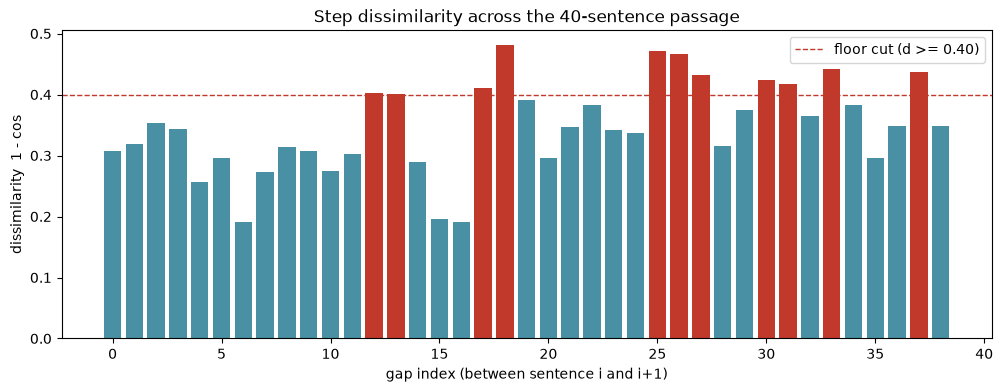

cut gaps: [12, 13, 17, 18, 25, 26, 27, 30, 31, 33, 37]


In [4]:
d = pipeline._step_dissimilarities(SENTENCES, embedder, window_size=4)
floor = 0.6
cut_line = 1.0 - floor
boundary = [i for i in range(len(d)) if pipeline._is_boundary(d, i, 15, 3.0)]
cut = [i for i in range(len(d)) if d[i] >= cut_line or i in boundary]
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(range(len(d)), d, color=['#c0392b' if i in cut else '#4a90a4' for i in range(len(d))])
ax.axhline(cut_line, color='#c0392b', linestyle='--', linewidth=1, label=f'floor cut (d >= {cut_line:.2f})')
ax.set_xlabel('gap index (between sentence i and i+1)')
ax.set_ylabel('dissimilarity  1 - cos')
ax.set_title('Step dissimilarity across the 40-sentence passage')
ax.legend()
plt.show()

print('cut gaps:', cut)

## Step 2: linear tiling (before the graph)

The tiler grows a window around each seed sentence, out to `group_max_len` (default 7), stopping at cut gaps. Overlapping windows are then deduplicated. These are the raw semantic units, in document order, shown by the sentence range each one covers.

In [5]:
groups = pipeline._build_groups(segments, embedder)
unique = pipeline._deduplicate_groups(groups)

print(f'raw groups: {len(groups)}, after dedup: {len(unique)}')

for g in unique:
    ids = [INDEX[s.text] for s in g]

    print(f'  s{min(ids):02d}..s{max(ids):02d} (n={len(g)}): {g[0].text[:64]}')

raw groups: 14, after dedup: 14
  s00..s06 (n=7): The city library lends books to any resident who holds a valid m
  s04..s10 (n=7): The standard loan period for a book is twenty-one days.
  s06..s12 (n=7): Borrowed books may be renewed twice if no other reader has reser
  s13..s13 (n=1): Returning a book on time keeps the member's account in good stan
  s14..s17 (n=4): A book returned after its due date incurs a fine of twenty cents
  s18..s18 (n=1): The block is lifted automatically the moment the balance falls b
  s19..s25 (n=7): Books may be returned to the front desk during opening hours.
  s26..s26 (n=1): Reference books and rare editions are marked as non-circulating 
  s27..s27 (n=1): These titles may only be consulted inside the reading room.
  s28..s30 (n=3): Children under twelve borrow on a junior card linked to a parent
  s31..s31 (n=1): However, DVDs may not be renewed and must be returned within the
  s32..s33 (n=2): Members can browse the full catalogue from home using 

## Step 3: semantic units grouped into Louvain communities

The units are embedded, connected into a kNN similarity graph, and clustered with Louvain community detection. This is where short units that share a subject are pulled back together, even when they are not adjacent in the text.

In [6]:
result = tile(segments, embedder=embedder)
n_units = sum(len(c.units) for c in result.communities)

print(f'communities: {len(result.communities)}, semantic units: {n_units}')

for c in result.communities:
    print(f'\ncommunity {c.id}  ({len(c.units)} units):')

    for u in c.units:
        print(f'    unit {u.id} [{len(u.sentences)} sent]: {u.sentences[0][:66]}')

communities: 3, semantic units: 14

community 0  (5 units):
    unit 0 [7 sent]: The city library lends books to any resident who holds a valid mem
    unit 1 [7 sent]: The standard loan period for a book is twenty-one days.
    unit 2 [7 sent]: Borrowed books may be renewed twice if no other reader has reserve
    unit 9 [3 sent]: Children under twelve borrow on a junior card linked to a parent's
    unit 10 [1 sent]: However, DVDs may not be renewed and must be returned within the f

community 1  (4 units):
    unit 4 [4 sent]: A book returned after its due date incurs a fine of twenty cents p
    unit 5 [1 sent]: The block is lifted automatically the moment the balance falls bac
    unit 6 [7 sent]: Books may be returned to the front desk during opening hours.
    unit 12 [4 sent]: A member who forgets their PIN can reset it by confirming their em

community 2  (5 units):
    unit 3 [1 sent]: Returning a book on time keeps the member's account in good standi
    unit 7 [1 sent]: Ref

## A look at the graph

Left: the unit-by-unit cosine similarity matrix, with units ordered by community, so a block structure means the communities are coherent. Right: the kNN relation graph, one node per unit, coloured by community.

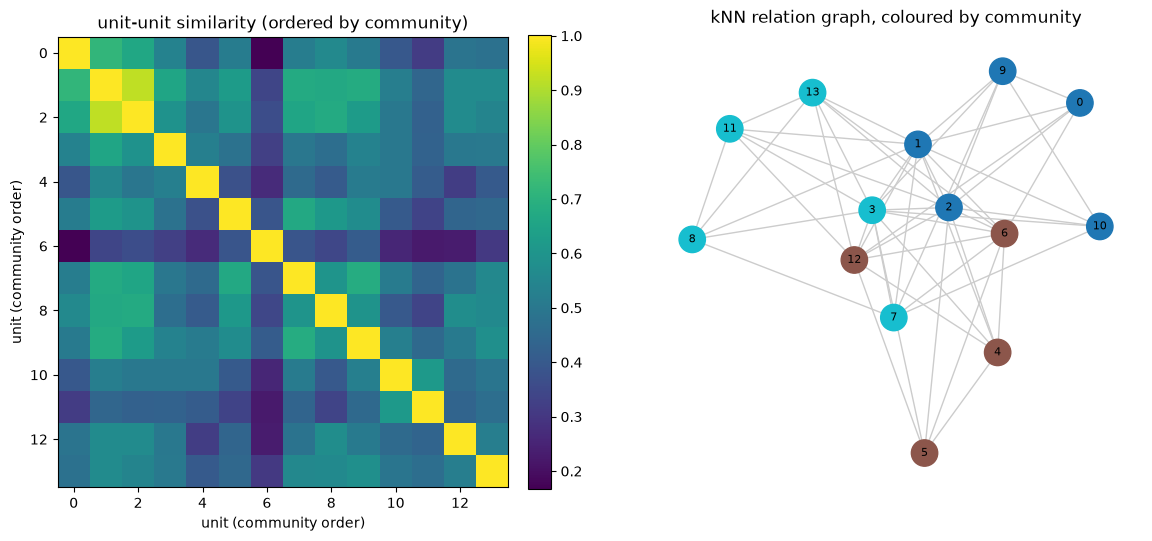

In [7]:
units = sorted((u for c in result.communities for u in c.units), key=lambda u: u.id)
unit_texts = [' '.join([*u.sentences, *u.payload]) for u in units]
emb = embedder.encode(unit_texts, normalize_embeddings=True)
sim = emb @ emb.T
adj = knn_sparsify(sim, 5)
G = nx.from_numpy_array(adj)
comm_of = {u.id: c.id for c in result.communities for u in c.units}
order = [u.id for c in result.communities for u in c.units]
S = sim[np.ix_(order, order)]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im = axes[0].imshow(S, cmap='viridis')

axes[0].set_title('unit-unit similarity (ordered by community)')
axes[0].set_xlabel('unit (community order)')
axes[0].set_ylabel('unit (community order)')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

pos = nx.spring_layout(G, seed=0)
colors = [comm_of[n] for n in G.nodes]

nx.draw(G, pos, ax=axes[1], node_color=colors, cmap='tab10', with_labels=True,
        node_size=360, font_size=8, edge_color='#cccccc')
axes[1].set_title('kNN relation graph, coloured by community')
plt.show()

## Sensitivity: how the unit count moves with `group_max_len`

The 7-sentence cap was chosen empirically. This sweep shows it is not a cliff: raising or lowering the cap trades unit count against unit length smoothly, and the Louvain layer keeps the community picture stable.

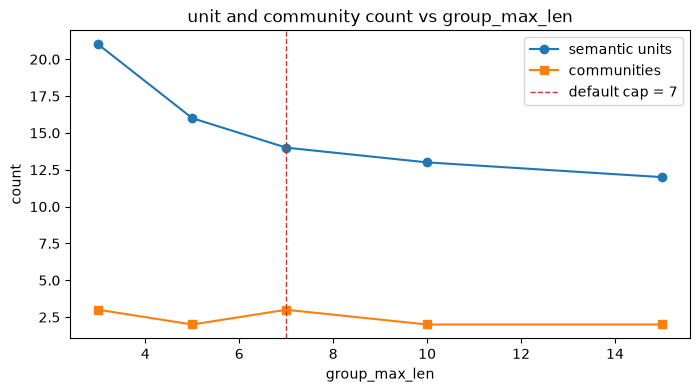

group_max_len: [3, 5, 7, 10, 15]
units       : [21, 16, 14, 13, 12]
communities : [3, 2, 3, 2, 2]


In [8]:
xs = [3, 5, 7, 10, 15]
units_y, comm_y = [], []

for gml in xs:
    r = tile(segments, embedder=embedder, group_max_len=gml)

    units_y.append(sum(len(c.units) for c in r.communities))
    comm_y.append(len(r.communities))

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(xs, units_y, marker='o', label='semantic units')
ax.plot(xs, comm_y, marker='s', label='communities')
ax.axvline(7, color='#c0392b', linestyle='--', linewidth=1, label='default cap = 7')
ax.set_xlabel('group_max_len')
ax.set_ylabel('count')
ax.set_title('unit and community count vs group_max_len')
ax.legend()
plt.show()

print('group_max_len:', xs)
print('units       :', units_y)
print('communities :', comm_y)

In [9]:
embedder.close()

## Observations

With the default cap (`group_max_len=7`): **40 sentences produced 14 semantic units in 3 communities.**

- **The cuts land on real sub-topic seams.** The dissimilarity spikes fall at the transitions between facets: reservations giving way to account standing and fines (gaps 12 to 13), fines giving way to the borrowing block (17 to 18), lost and damaged books giving way to reference titles (25 to 27), the audiobook and DVD rule (30 to 31), the online catalogue (33), and the reminders and privacy at the end (37). None of them fall in the middle of a facet.
- **Short solo units appear exactly where the design expects them.** Single-sentence units show up at sharp local shifts (returning on time, the block being lifted, the reading-room rule, the DVD renewal exception). These are not a defect: the Louvain layer folds them back together with related material, which is the whole reason units are allowed to stay short.
- **The three communities read as coarse themes.** Community 0 is borrowing and the loan period (including junior cards and the DVD renewal rule); community 1 is money and physical return (the fines, the borrowing block, the return bin), with PIN reset pulled in as an account-access outlier; community 2 collects the more standalone facets (reference and reading room, the online catalogue, privacy). Sensible rather than perfect: community 1 mixes account state with PIN reset, and community 2 is a looser catch-all, which is the expected shape when one topic is sliced fine and then re-clustered.
- **No cliff at 7.** Sweeping the cap from 3 to 15 moves the unit count 21, 16, 14, 13, 12 while the community count stays between 2 and 3. The cap trades unit granularity smoothly and the community picture is stable, which is exactly what the two-stage design is meant to buy.

**Verdict.** On a long single-topic passage the tiler neither shatters the text into noise nor collapses it into one blob. It cuts at genuine sub-topic seams, keeps units short and sharp, and lets the community layer restore the topic-level view.